In [1]:
from utils.paths import SAMPLING_DIR, RAW_DIR,PREDICTIONS_DIR,PLOTS_DIR,DATABASE_DIR

In [32]:
import numpy as np
import pandas as pd
import pickle

from preprocessing.database_manager import DatabaseManager
from models_scripts.AdaptiveTransferKernel import AdaptiveTransferKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from preprocessing.DescriptorEngineer import AlloyDescriptorCalculator,ElementPropertyLoader
from preprocessing.DataPreprocessor import DataPreprocessor, DataSplitter
from preprocessing.Physics import DrudeAlloyModel
from preprocessing.TernaryPlot import plot_ternary_heatmap

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

In [4]:
#========= Experimental compositions ================
db = DatabaseManager(DATABASE_DIR/"Ternary_round1.db")

df_optical = db.table_dataframe('Optical_properties')
df_comp = db.table_dataframe('compositions')
db.close()

df_merged = df_optical.merge(df_comp, on="ID", how="inner")
tern_1550 = df_merged[np.isclose(df_merged["wavelength_nm"].astype(float), 1552.0)]

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [34]:
loader = ElementPropertyLoader()
elem_props = loader.load()
calc = AlloyDescriptorCalculator(elem_props=elem_props)
dp = DataPreprocessor()


In [6]:
X = tern_1550[['Cu','Ni','Al']].copy()
y = tern_1550['e2'].copy()

In [7]:
splitter = DataSplitter(
    test_size=0.2,
    random_state=42,
    split_method="random"
)

random_split = splitter.split_training(X, y)

splitter = DataSplitter(
    test_size=0.05,
    random_state=42,
    split_method="cluster",
    n_clusters =6,
    cluster_feature_start= 0
)

cluster_split = splitter.split_training(X, y)

In [8]:
feature_cols = ['Cu','Ni','Al','r','del_r','del_EN','S','VEC']

x_train_rd, x_test_rd, y_train_rd, y_test_rd,scaler_rd = dp.train_test(
    random_split,
    calc,
    feature_cols,
    scaler = None
)

x_train_cl, x_test_cl, y_train_cl, y_test_cl,scaler_cl = dp.train_test(
    cluster_split,
    calc,
    feature_cols,
    scaler = None
)

Experimental data GP - Random splitting

In [9]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))
)

gpr_nt_ran = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_ran.fit(x_train_rd, y_train_rd)
print("Learned kernel:", gpr_nt_ran.kernel_)

Learned kernel: 1.01**2 * Matern(length_scale=1.46, nu=2.5) + WhiteKernel(noise_level=0.269)


In [10]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_rd, error_rd = dp.gp_predict_and_errors(calc,x_all,gpr_nt_ran,scaler_rd,x_test_rd,y_test_rd,feature_cols)

df1 = random_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_rd['df_residuals'].reset_index(drop=True)
df_test_rd = pd.concat([df1,df2], axis=1)

Plots [Predicted plot and erro plot]

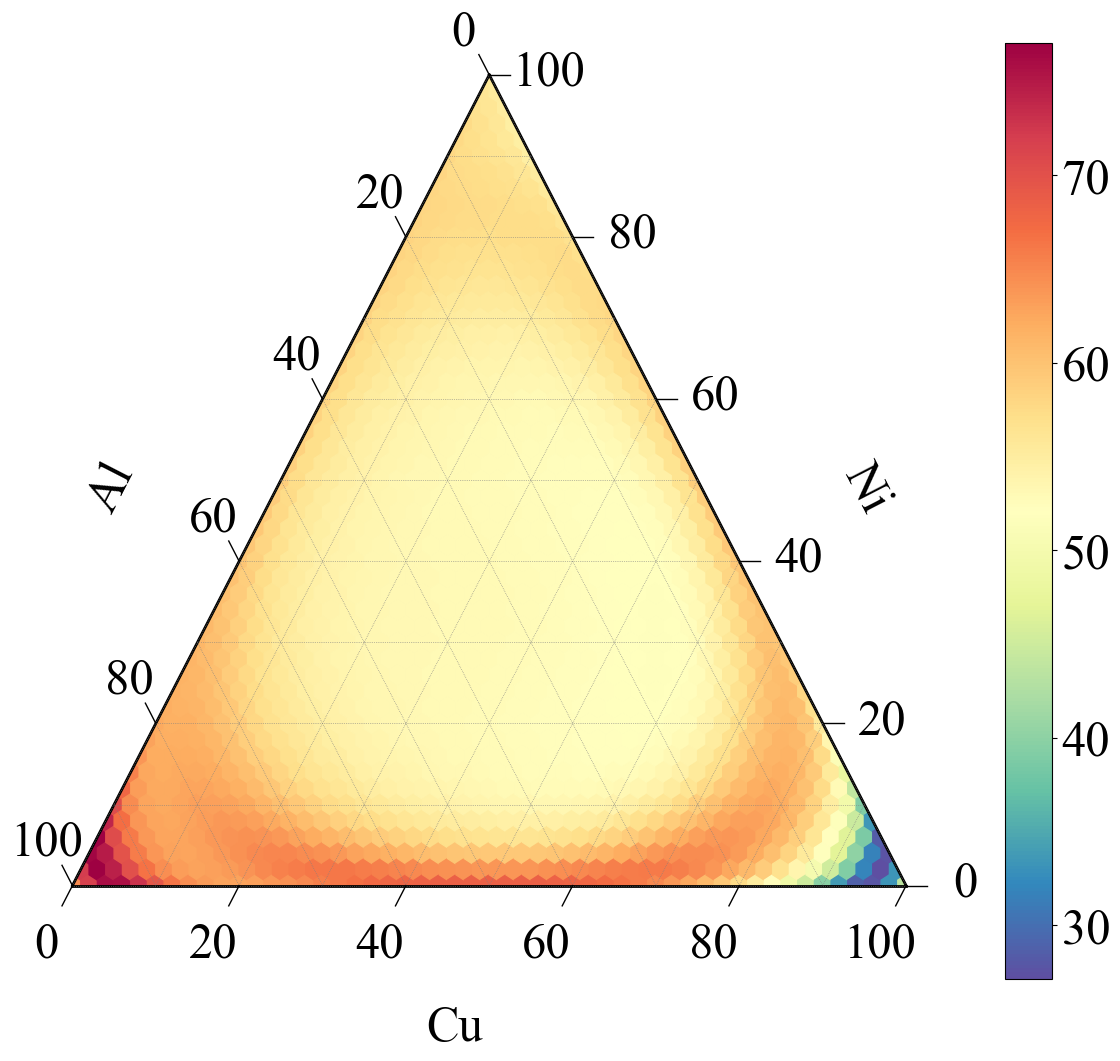

In [11]:
df_pred_rd[comp_cols] = df_pred_rd[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_PG_Random_split.svg", bbox_inches="tight")

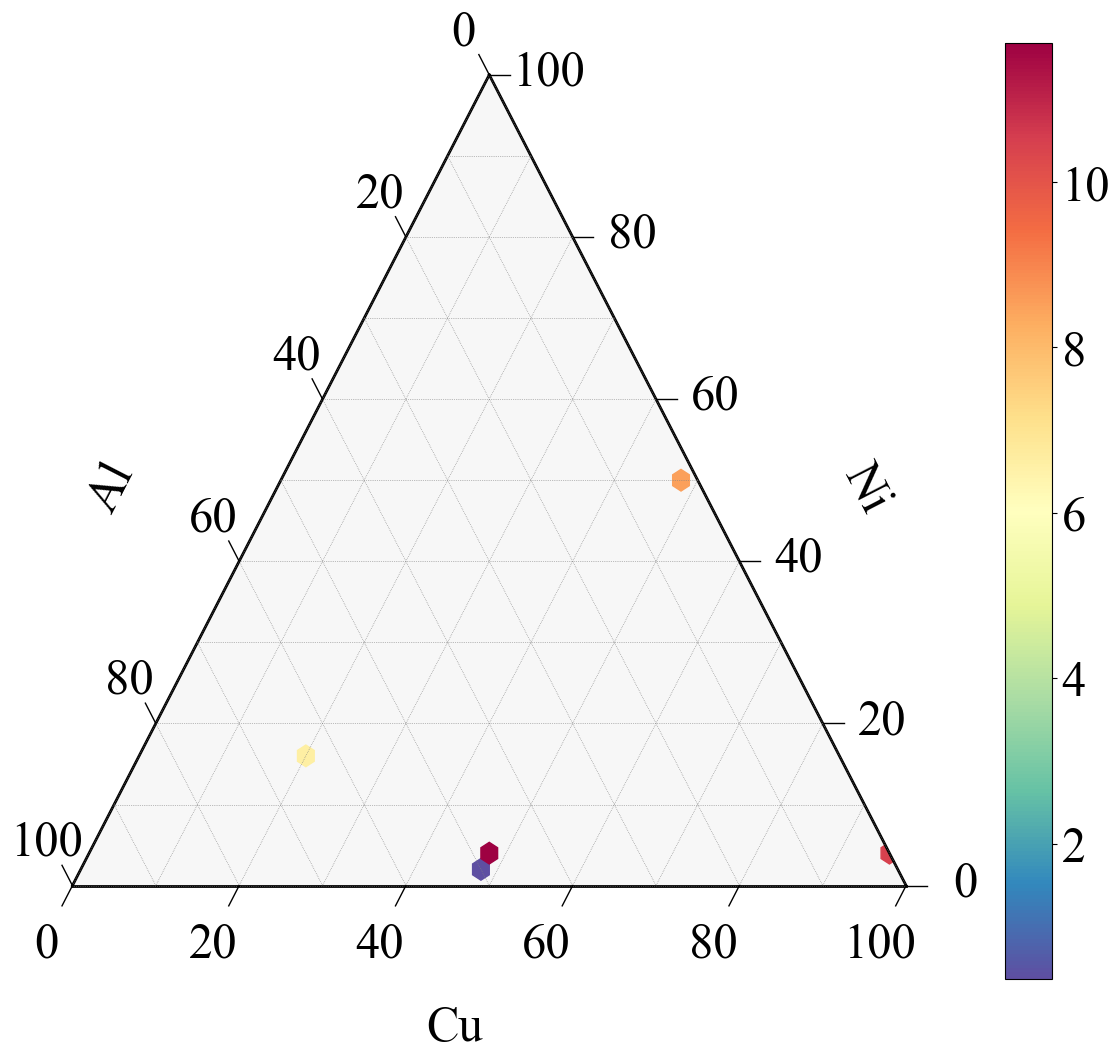

In [12]:
fig, tax = plot_ternary_heatmap(
    df=df_test_rd,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_GP_error_rand_split.svg", bbox_inches="tight")


Experimental data GP - Kmeans splitting

In [14]:
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gpr_nt_clus = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.0,   
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gpr_nt_clus.fit(x_train_cl, y_train_cl)
print("Learned kernel:", gpr_nt_clus.kernel_)

Learned kernel: 0.922**2 * Matern(length_scale=1.31, nu=2.5) + WhiteKernel(noise_level=0.337)


In [15]:
comp_cols = ['Cu','Ni','Al']
x_all = comp_space[['Cu','Ni','Al']]
df_pred_cl, error_cl = dp.gp_predict_and_errors(calc,x_all,gpr_nt_clus,scaler_cl,x_test_cl,y_test_cl,feature_cols)

df1 = cluster_split['X_test_split'].reset_index(drop=True)
df1 = df1*100
df2 = error_cl['df_residuals'].reset_index(drop=True)
df_test_cl = pd.concat([df1,df2], axis=1)

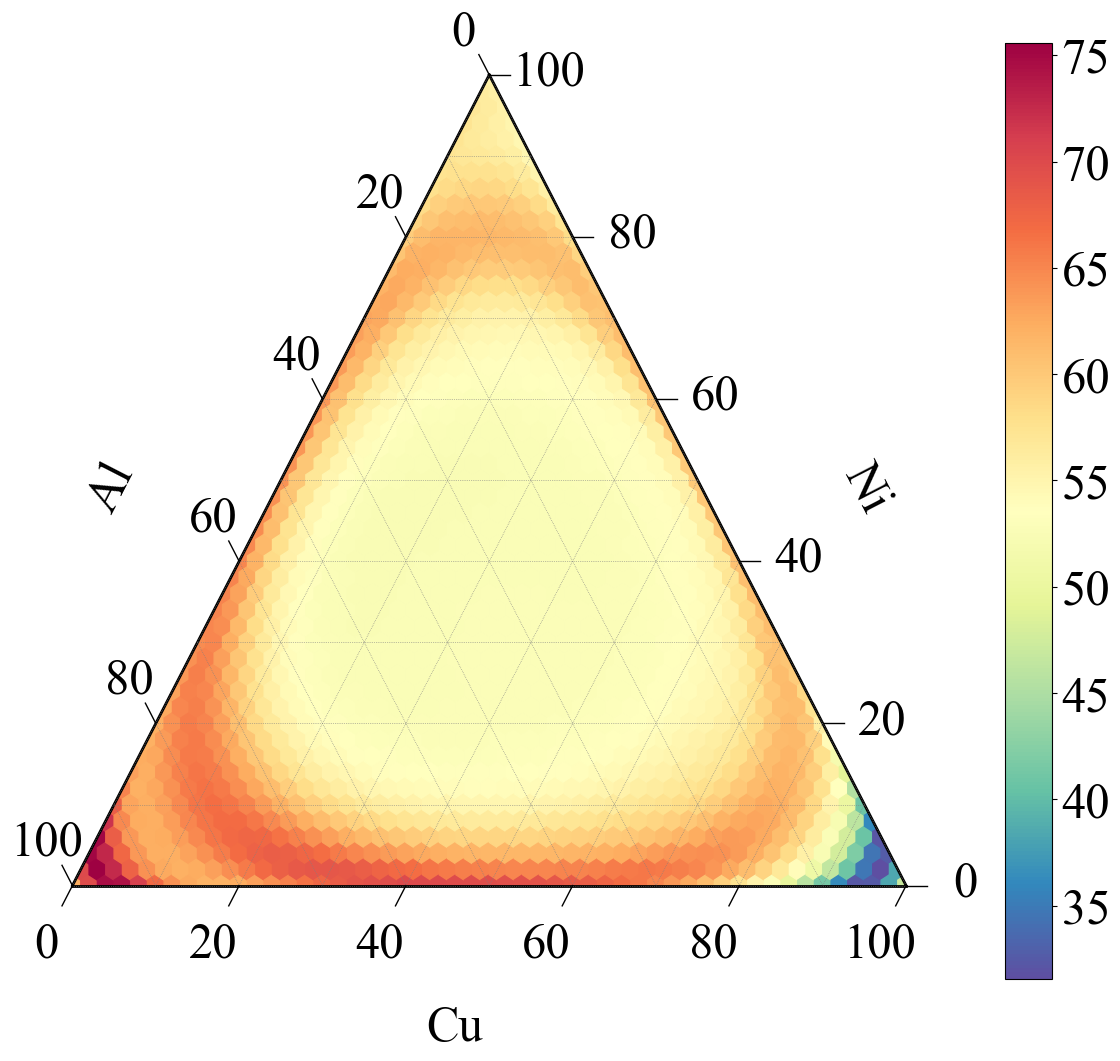

In [17]:
df_pred_cl[comp_cols] = df_pred_cl[comp_cols]*100
fig, tax = plot_ternary_heatmap(
    df=df_pred_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split.svg", bbox_inches="tight")

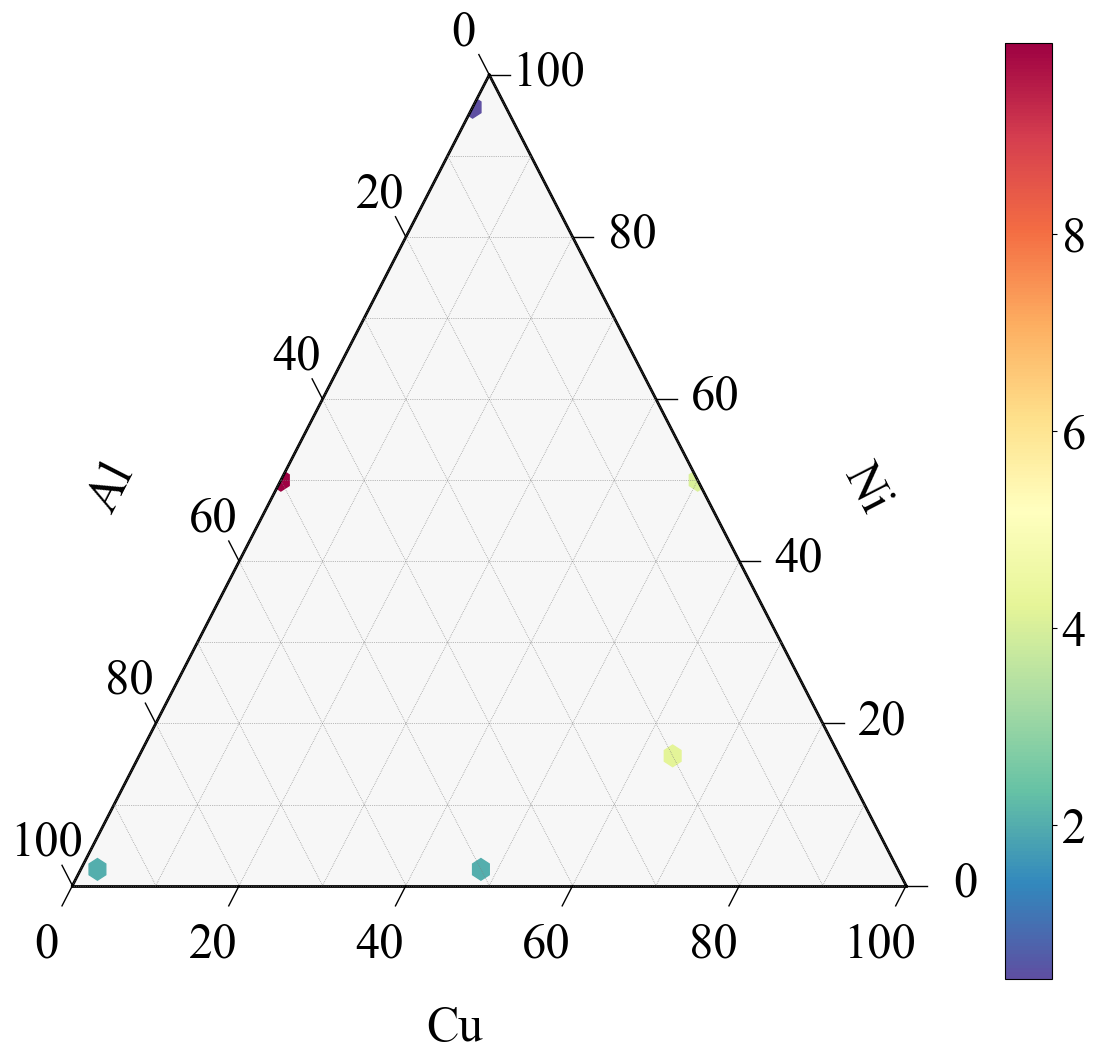

In [18]:
fig, tax = plot_ternary_heatmap(
    df=df_test_cl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_PG_cluster_split_error.svg", bbox_inches="tight")

Gaussina Process Residual Approach

In [50]:
experimental_space = pd.read_pickle(PREDICTIONS_DIR/"ANN_Predictions/experimental_resis_prediction.pkl")
experimental_space['resistivity'] = experimental_space['resistivity'] *1e-8
exp_resis_prediction = experimental_space[['Cu','Ni','Al','resistivity']]

comp_cols = ['Cu','Ni','Al']
X_physics_train = cluster_split['X_train_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')

In [ ]:
# Drude model class for e2 calculation
elem_cols = ["Cu","Al","Ni"]
ne_pure = [8.47e28,18.1e28,5.64e28]
drude = DrudeAlloyModel(elem_cols=elem_cols,ne_pure=ne_pure,wavelength_unit='nm')

df_physics_train = drude.predict_dataframe(df =X_physics_train,rho_col='resistivity',wvl=1550)

In [ ]:
#. Residuals
y_phys_train = np.asarray(df_physics_train['e2_drude'])
y_res_train = cluster_split['y_train'] - y_phys_train

In [65]:
# Fit GP on residuals
kernel = (
    C(1.0, (1e-3, 1e3)) *
    Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
    + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
)

gp_res = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=10,
    normalize_y=True
)
gp_res.fit(x_train_cl, y_res_train)
print("Learned kernel:", gp_res.kernel_)

Learned kernel: 1.01**2 * Matern(length_scale=1.45, nu=2.5) + WhiteKernel(noise_level=0.303)


In [72]:
X_phys_test = cluster_split['X_test_split'].merge(experimental_space[comp_cols+['resistivity']], on=comp_cols, how='left')
df_physics_test = drude.predict_dataframe(df =X_phys_test,rho_col='resistivity',wvl=1550)

y_phys_test = np.asarray(df_physics_test['e2_drude'])

In [82]:
# Predict on new points
y_res_pred, y_res_std = gp_res.predict(x_test_cl, return_std=True)

# Final Prediction
y_predic = y_phys_test + y_res_pred

In [85]:
error_cl

{'mae': 3.7664437287334955,
 'rmse': 4.842719933918951,
 'r2': 0.6699479449662948,
 'df_residuals':       y_true     y_pred     error  error_abs   error_sq
 0  55.827915  59.865334 -4.037419   4.037419  16.300753
 1  54.283161  64.217076 -9.933915   9.933915  98.682667
 2  50.837952  55.021145 -4.183193   4.183193  17.499101
 3  62.303177  64.312865 -2.009688   2.009688   4.038845
 4  56.649986  57.083952 -0.433966   0.433966   0.188327
 5  76.665421  74.664940  2.000481   2.000481   4.001926}

In [83]:
y_predic

array([51.5056446 , 64.52029065, 60.29462597, 64.55515143, 46.47692946,
       82.54243983])

In [77]:
## Error calculation
# Metrics
mse_res = mean_squared_error(cluster_split['y_test'], y_predic)
rmse_res = np.sqrt(mse_res)
r2_res = r2_score(cluster_split['y_test'], y_predic)

print("Residual GP Performance:")
print(f"MSE:  {mse_res:.4f}")
print(f"RMSE: {rmse_res:.4f}")
print(f"R2:   {r2_res:.4f}")

Residual GP Performance:
MSE:  59.3352
RMSE: 7.7029
R2:   0.1649


GPy module installation

In [ ]:
import GPy
# Mean function
mf = GPy.core.Mapping (input_dim=1, output_dim=1)
mf.f = lambda X: np.sin(X)
mf.update_gradients = lambda dL_dF, X:None

# Kernel
k = GPy.kern.RBF(input_dim=1)

#GP model with custom mean
m =  GPy.models.GPRegression(X, Y, kernel=k, mean_function=mf)

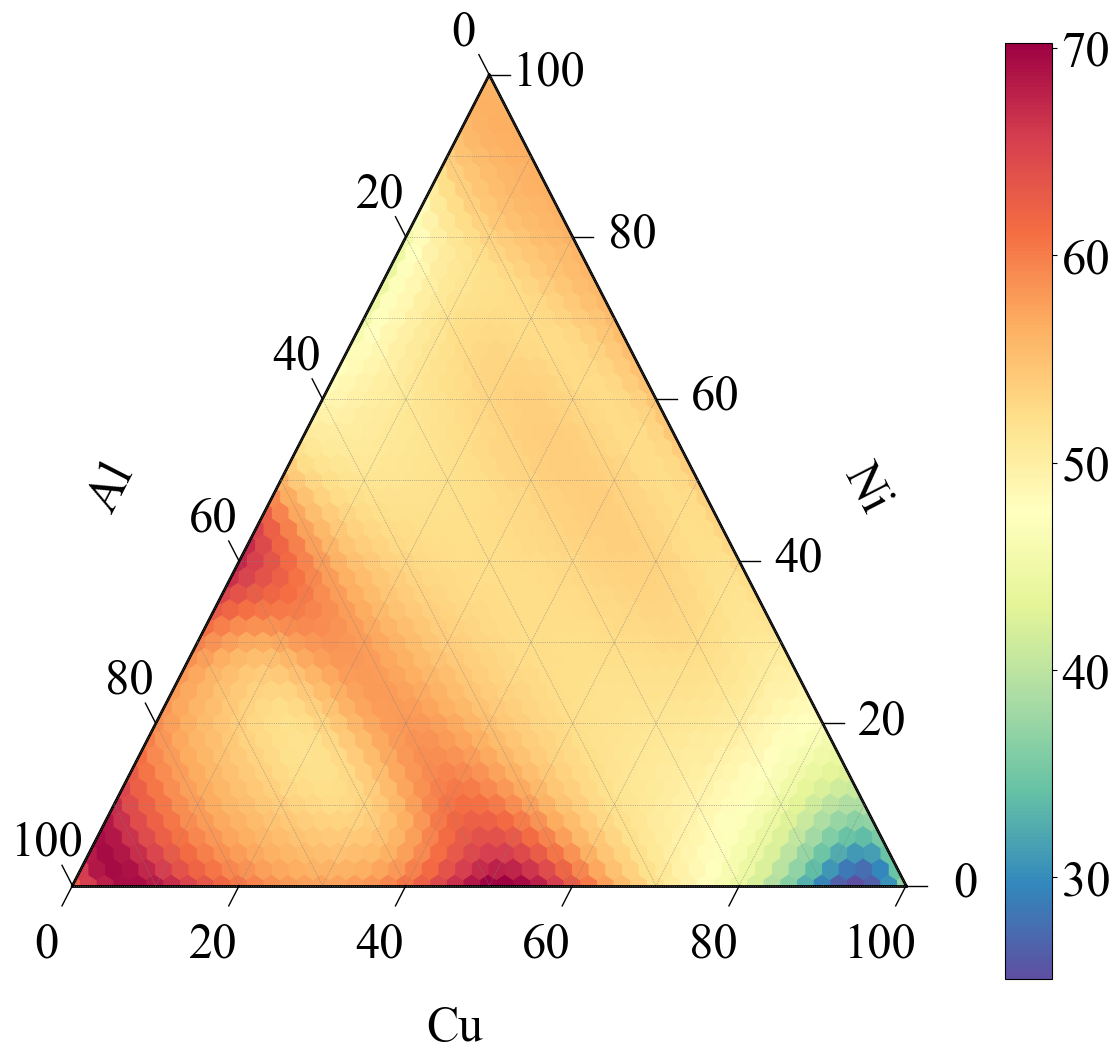

In [231]:
e2_predict_GP_exp =  np.load(PREDICTIONS_DIR/"GP-Experiments/e2_predicted_GP.npy")

df_previous_split = df_cluster_split[composition_cols].copy()

df_previous_split["e2"] = e2_predict_GP_exp

fig, tax = plot_ternary_heatmap(
    df=df_previous_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

fig.savefig(PLOTS_DIR/"ternary_GP_cluster_split_initial.svg", bbox_inches="tight")

In [232]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

df_test = data_cluster['X_test_split_full']
comp_cols = ["Cu", "Ni", "Al"]
df_test = df_test[['Cu','Ni','Al']]*100
df_test['y_test'] = data_cluster['y_test']



X_test = df_test[comp_cols].to_numpy(dtype=float)
X_big = df_previous_split[comp_cols].to_numpy(dtype=float)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_big)

distances, indices = nn.kneighbors(X_test)

distances = distances.ravel()
indices = indices.ravel()

matched = df_previous_split.iloc[indices].reset_index(drop=True)
df_compare = df_test.reset_index(drop=True).copy()

df_compare["e2_pred"] = matched["e2"].to_numpy()
df_compare["match_distance"] = distances
df_compare["error"] = df_compare["y_test"] - df_compare["e2_pred"]
df_compare["abs_error"] = np.abs(df_compare["error"])
df_compare["sq_error"] = df_compare["error"] ** 2

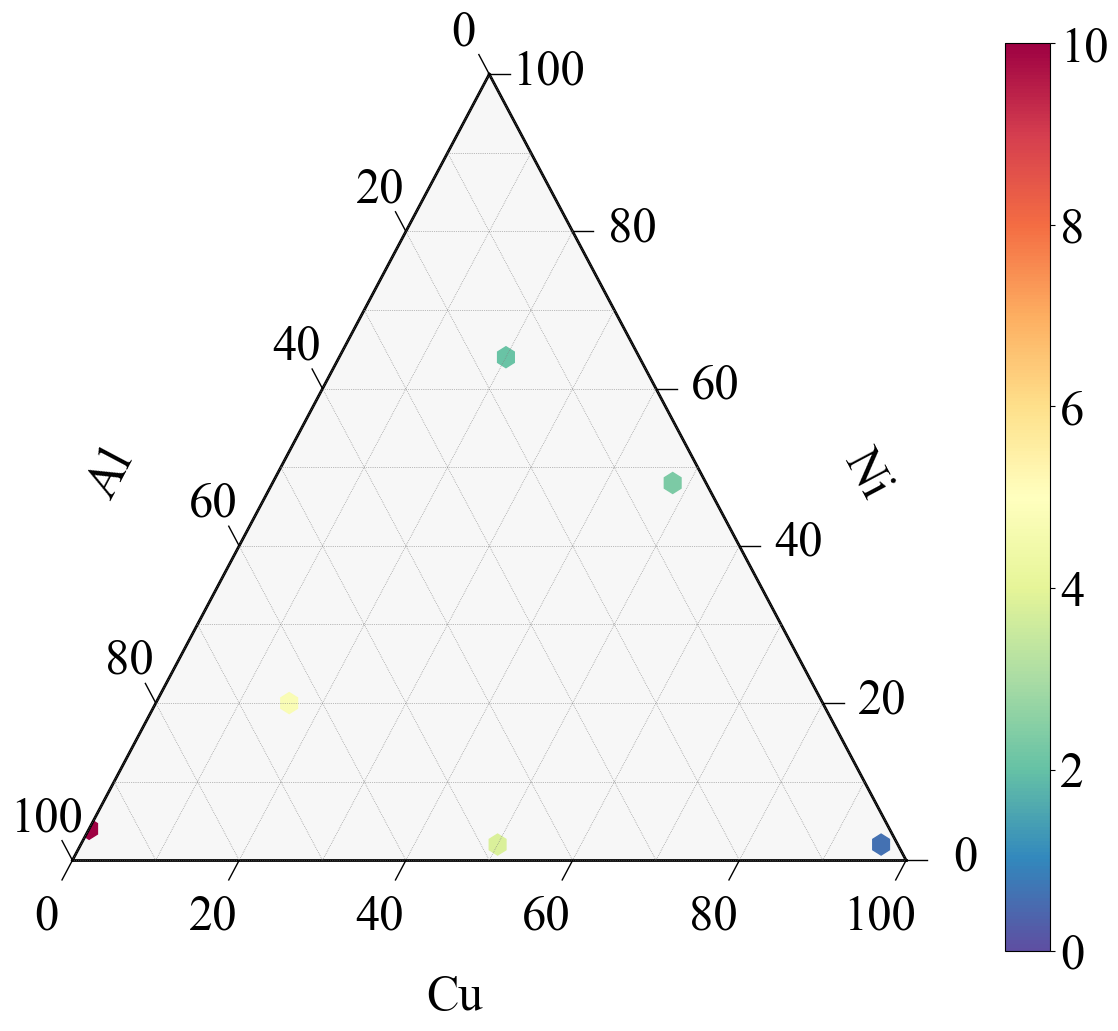

In [239]:
fig, tax = plot_ternary_heatmap(
    df=df_compare,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="abs_error",
    scale=50,
    cmap="Spectral_r",
    vmin=0,
    vmax=10,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_GP_cluster_split_initial_error.svg", bbox_inches="tight")

Adaptive kernel approach

In [ ]:
# Source and target variables for Adaptive transfer kernel

def data_transfer_gp (X_source,X_target, y_source, y_target):
    # Convert to numpy
    Xs = np.asarray(X_source, dtype=float)
    Xt = np.asarray(X_target, dtype=float)
    
    # Add domain indicator ( 0 = source, 1 = target)
    Xs_aug = np.c_[Xs, np.zeros((len(Xs),1))]
    Xt_aug = np.c_[Xt, np.ones((len(Xt),1))]
    
    #combine datasets
    X_train = np.vstack([Xs_aug, Xt_aug])
    y_train = np.concatenate([y_source, y_target])
    
    return X_train,y_train

In [ ]:
feature_cols = ['VEC','del_EN']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=True
)

In [ ]:
feature_cols = ['VEC','del_EN']
composition_cols = ['Cu','Ni','Al']

elec_resis = np.load(PREDICTIONS_DIR/"ANN_Predictions/electrical_resistivity_predicted.npy")
tl_gp = comp_space.copy()
tl_gp['resistivity'] = elec_resis


X_source = tl_gp[feature_cols]
X_target = cluster_split['X_train_split'][feature_cols]
y_source = tl_gp['resistivity']
y_target = cluster_split["y_train"]


x_train,y_train = data_transfer_gp(X_source,X_target,y_source,y_target)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from models_scripts.AdaptiveTransferKernel import AdaptiveTransferKernel

kernel = AdaptiveTransferKernel(
    kernel=1.0 * Matern(length_scale=1.0, nu=2.5),
    lamb=2.0,
    lamb_bounds=(1.0, 3.0),
    different_noises=False,
)

gpr_pe = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-5,            # jitter for numerical stability
    normalize_y=True,      # y standardization inside sklearn
    n_restarts_optimizer=3 # increase later (5-10) if slow/unstable
)

gpr_pe.fit(x_train, y_train)
print("Learned kernel:", gpr_pe.kernel_)

Learned kernel: AdaptiveTransferKernel(0.00792, -11.5, 0.438)


/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


In [ ]:

feature_cols = ['VEC','del_EN']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=False
)
ones = np.ones(len(data_cluster['X_test_proc']))
data_cluster['X_test_proc'] = np.column_stack((data_cluster['X_test_proc'],ones))
data_cluster['X_train_split_full']["source"] = np.ones(len(data_cluster['X_train_split_full']))
data_cluster['X_test_split_full']["source"] = np.ones(len(data_cluster['X_test_split_full']))
comp_space["source"] = np.ones(len(comp_space))

feature_cols = ['VEC','del_EN','source']

gp_tl, df_tl_gp, df_test_tl = evaluate_and_predict_space(
    model=gpr_pe,
    data_dict=data_cluster,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=False,
    pred_col="e2"
)

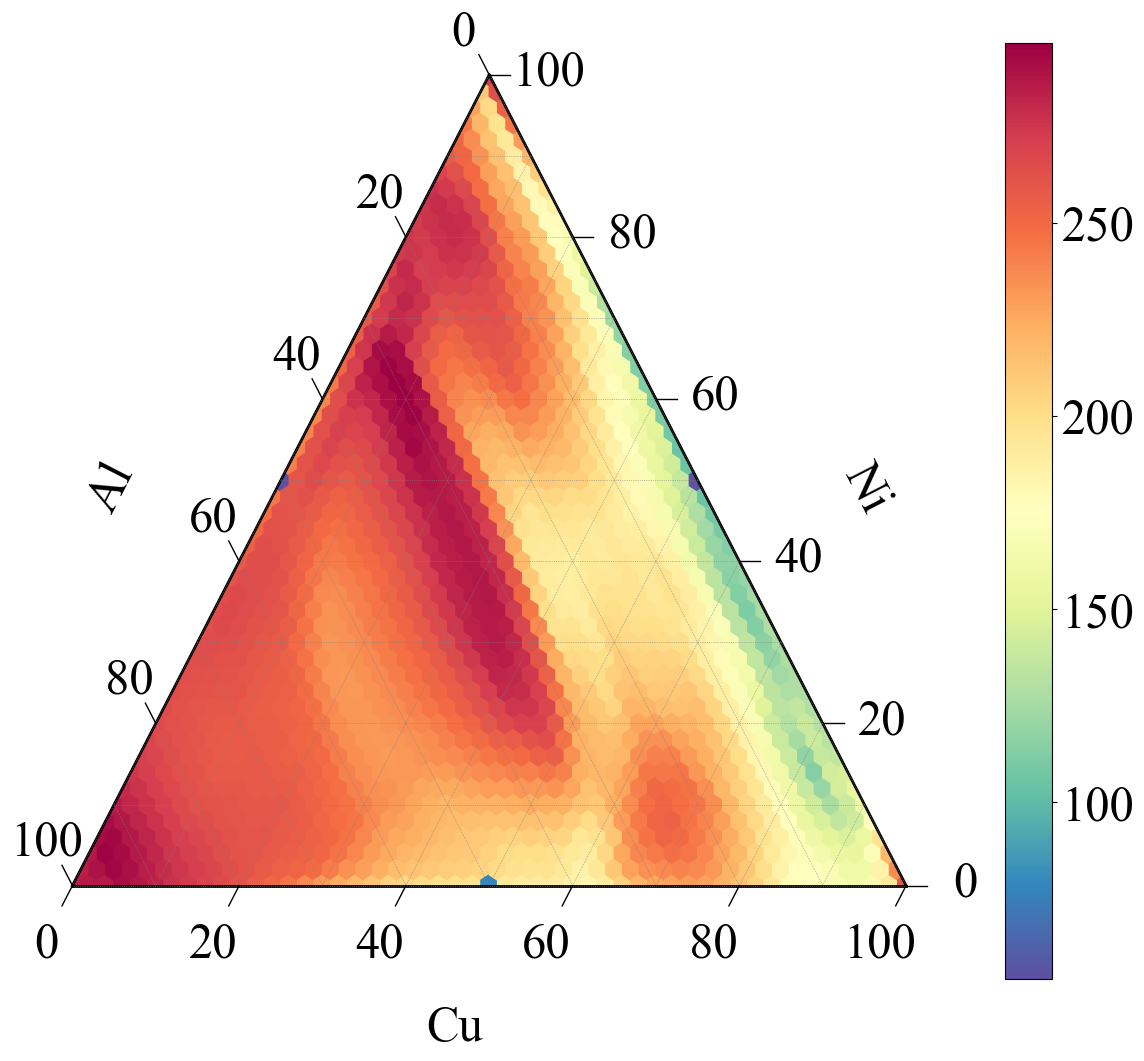

In [ ]:
fig, tax = plot_ternary_heatmap(
    df=df_tl_gp,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

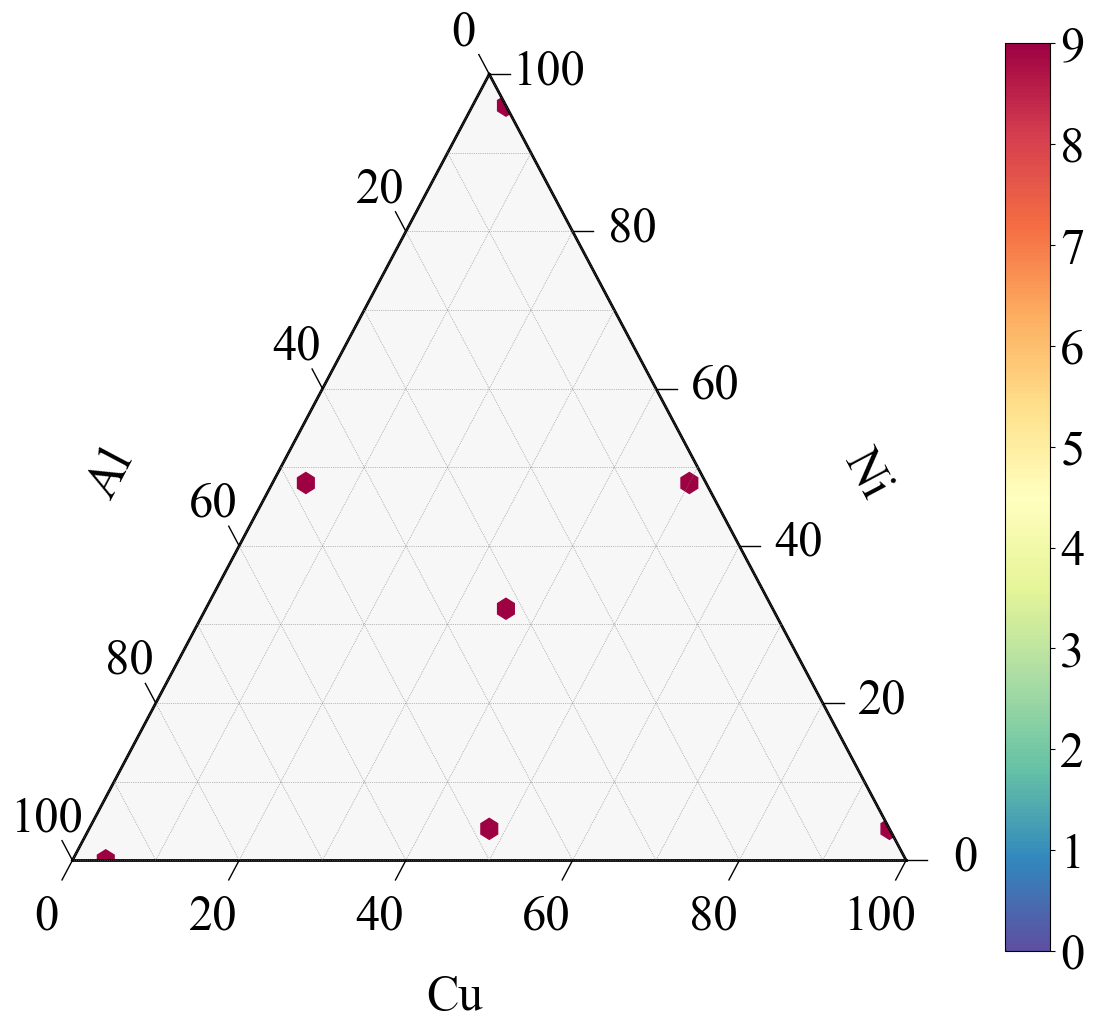

In [ ]:
fig, tax = plot_ternary_heatmap(
    df=df_test_tl,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)

In [235]:
import numpy as np
import pandas as pd
import copy

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel


def build_gp_model():
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e0))
    )

    model = GaussianProcessRegressor(
        kernel=kernel,
        alpha=0.0,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=None
    )
    return model


def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "r2": r2_score(y_true, y_pred),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "mse": mean_squared_error(y_true, y_pred),
    }


def repeated_split_model_selection(
    X, y,
    n_splits=100,
    test_size=0.15,
    random_seed=42,
    selection_metric="rmse",
    maximize_metric=False
):

    rng = np.random.default_rng(random_seed)

    results = []
    best_model = None
    best_score = -np.inf if maximize_metric else np.inf

    best_split_data = None

    for i in range(n_splits):

        split_seed = int(rng.integers(0, 1_000_000))

        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=test_size, random_state=split_seed
        )

        model = build_gp_model()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)

        metrics = evaluate_regression(y_val, y_pred)
        score = metrics[selection_metric]

        results.append({
            "split": i,
            "seed": split_seed,
            **metrics,
            "kernel": str(model.kernel_)
        })

        is_better = score > best_score if maximize_metric else score < best_score

        if is_better:
            best_score = score
            best_model = copy.deepcopy(model)

            best_split_data = {
                "split": i,
                "seed": split_seed,
                "train_indices": X_train.index,
                "test_indices": X_val.index
            }

    results_df = pd.DataFrame(results).sort_values(
        selection_metric,
        ascending=not maximize_metric
    )

    return best_model, best_split_data, results_df

In [236]:
feature_cols = ['del_r','VEC','del_EN']
composition_cols = ['Cu','Ni','Al']

data_cluster = prepare_train_test_data(
    split_dict=cluster_split,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    standardize=True
)

In [266]:

x_before = np.vstack((data_cluster['X_train_proc'],data_cluster['X_test_proc']))
y_before = np.hstack((data_cluster['y_train'],data_cluster['y_test']))

df1 = data_cluster['X_train_split_full'][['Cu','Ni','Al']]
df2 = data_cluster['X_test_split_full'][['Cu','Ni','Al']]
x_comp = pd.concat([df1,df2],axis=0)

In [267]:
X = pd.DataFrame(x_before,columns=feature_cols)
y = pd.DataFrame(y_before)

best_model, best_split, results = repeated_split_model_selection(
    X,
    y,
    n_splits=200,
    test_size=0.22,
    selection_metric="rmse",
    maximize_metric=False
)

In [268]:
X_train = X.iloc[best_split['train_indices']]
y_train = y.iloc[best_split['train_indices']]

X_test = X.iloc[best_split['test_indices']]
x_comp_test = x_comp.iloc[best_split['test_indices']]
y_test = y.iloc[best_split['test_indices']]

X_test = pd.concat(
    [x_comp_test.reset_index(drop=True), X_test.reset_index(drop=True)],
    axis=1
)

In [269]:
data_smart_split = {}
data_smart_split['scaler'] = data_cluster['scaler']
data_smart_split['X_test_split_full'] = X_test
data_smart_split['X_test_proc'] = X_test[feature_cols]
data_smart_split['y_test'] = y_test
data_smart_split['standardize'] = data_cluster['standardize']

/Users/linarojas/opt/anaconda3/envs/Python310/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianProcessRegressor was fitted with feature names
  warnings.warn(


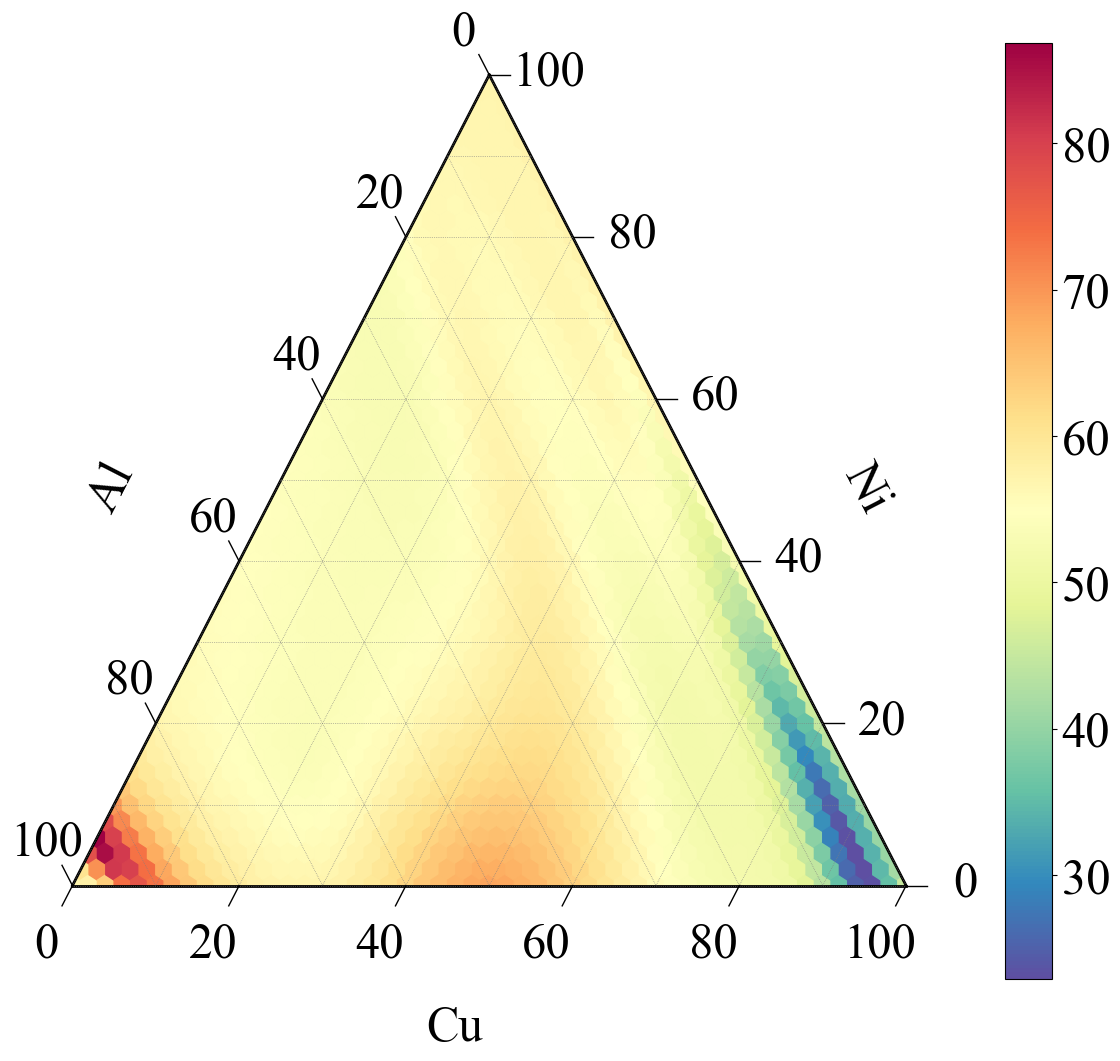

In [270]:
gp_cluster_split, df_cluster_split, df_test_clus = evaluate_and_predict_space(
    model=best_model,
    data_dict=data_smart_split,
    comp_space=comp_space,
    feature_cols=feature_cols,
    composition_cols=composition_cols,
    return_std=True,
    save=False,
    pred_col="e2"
)

fig, tax = plot_ternary_heatmap(
    df=df_cluster_split,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="e2",
    scale=50,
    cmap="Spectral_r",
    vmin=None,
    vmax=None,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_GP_smart_split_.svg", bbox_inches="tight")

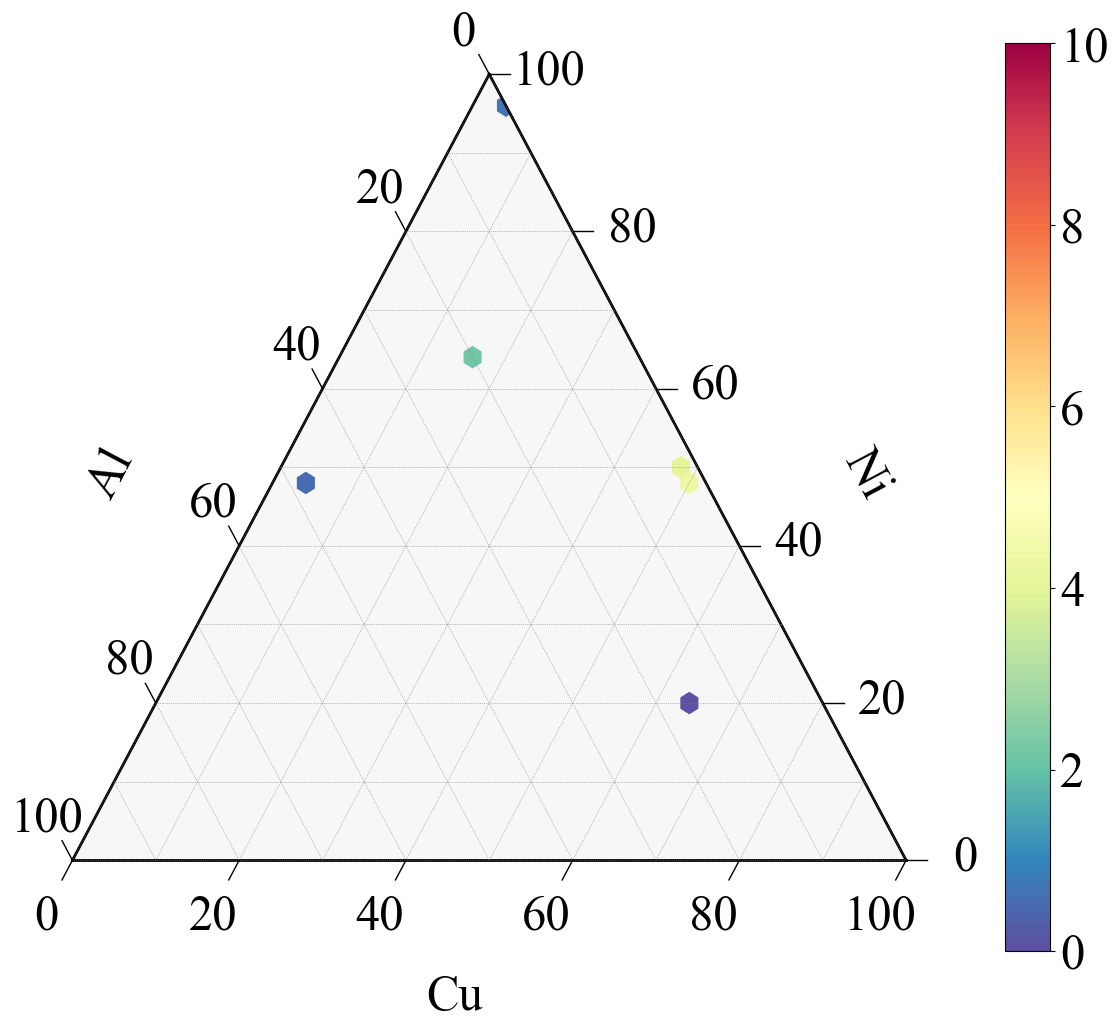

In [272]:
fig, tax = plot_ternary_heatmap(
    df=df_test_clus,
    comp_cols=("Cu", "Ni", "Al"),
    value_col="y_error_abs",
    scale=50,
    cmap="Spectral_r",
    vmin=0,
    vmax=10,
    show=True,
    duplicate_handling="mean",
)
fig.savefig(PLOTS_DIR/"ternary_GP_smart_split_error.svg", bbox_inches="tight")